# **Predição de arritmias em sinais de ECG de longa duração**


---
Alexandre Goldfajn e
Gustavo Cruz



# 1. Introdução e Contexto Médico


---

Após o término do exame Holter, o profissional recebe um arquivo de sinal bruto, remove ruído manualmente, e verifica o que o computador aponta como anormalidade numa série temporal podendo confirmar ou recusar tal apontamento. Além disso, verifica frequências máximas, mínimas, médias e desvios, buscando também as pausas. Com isso, forma-se um relatório quantitativo e qualitativo. A ideia aqui é facilitar tais funções, criando um ML que filtra a informação e interpreta as anormalidades da série temporal, assim como as métricas de média de frequencia etc para então indicar o diagnóstico do paciente.

Metrics: Deseja-se principalmente atingir uma alta sensibilidade e F1 score (pois os batimentos anormais representam uma quantidade pequena em relação aos normais)


# 2. Configuração do Ambiente e Bibliotecas
Instalações e importações necessárias para o notebook.
Obs: recomenda-se o ambiente de execução GPU T4

In [ ]:
# --- INSTALAÇÕES ---
!pip install wfdb imbalanced-learn -q  # Leitura de sinais médicos e SMOTE (usado no V3)

# --- BIBLIOTECAS PADRÃO E TRATAMENTO DE DADOS ---
import os
import wfdb
import pandas as pd
import numpy as np
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# --- VISUALIZAÇÃO DE DADOS ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- DEEP LEARNING (TENSORFLOW/KERAS) ---
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Input, Dense, Dropout, LSTM
# Específicos do V3:
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Bidirectional

# --- MÉTRICAS E BALANCEAMENTO ---
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils import class_weight  # Usado no V2 para compensar desbalanceamento
from imblearn.over_sampling import SMOTE  # Usado no V3 para criar dados sintéticos da Classe A

# --- CONFIGURAÇÃO DE ESTABILIDADE (OPCIONAL) ---
np.random.seed(42)
tf.random.set_seed(42)

# --- Salvar o documento ---
import pickle
print(" Ambiente configurado e organizado!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 114.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.2 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.2 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.2 which is incompatible.
dask-cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.2 which is incompatible.
db-dtypes 1.5.1 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.2 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.2 which is incompatible.
 Ambiente config

#3. Aquisição e Extração de Dados (MIT-BIH Database)


---
A base de dados [MIT-BIH Arrhythmia Database](https://physionet.org/content/mitdb/1.0.0/ )  abrange um total de 48 registros de exames de eletrocardiograma (Holter), com uma duração de 30 minutos cada, totalizando aproximadamente 24 horas de monitoramento cardíaco. Os dados são organizados e rotulados de acordo com a morfologia dos batimentos e o diagnóstico clínico.

Para cada registro, são fornecidos 3 arquivos essenciais:

* .dat: O arquivo binário que contém o sinal de ECG digitalizado.

* .hea: O cabeçalho (header) que descreve os ganhos, frequência de amostragem (360 Hz) e informações do paciente.

* .atr: As anotações médicas (labels) que indicam a posição exata e o tipo de cada batimento.



In [ ]:

# Pasta para o protótipo
data_dir = 'mit_bih_prototype'
if not os.path.exists(data_dir):
    os.makedirs(data_dir)

# Registros selecionados:
# 100: Base Normal
# 119, 200: Muita Arritmia Ventricular (V)
# 109, 118: Bloqueios de Ramo (L, R)
# 207: Casos complexos/ruído.
# 213: Misto
prototype_records = ['100', '109', '118', '119', '200', '207', '213']

wfdb.dl_database('mitdb', data_dir, records=prototype_records)
print("Arquivos do protótipo baixados")

Generating record list for: 100
Generating record list for: 109
Generating record list for: 118
Generating record list for: 119
Generating record list for: 200
Generating record list for: 207
Generating record list for: 213
Generating list of all files for: 100
Generating list of all files for: 109
Generating list of all files for: 118
Generating list of all files for: 119
Generating list of all files for: 200
Generating list of all files for: 207
Generating list of all files for: 213
Finished downloading files
Arquivos do protótipo baixados


#4. Análise Exploratória de Dados (EDA)


---

Nesta fase, realizamos uma Análise Exploratória de Dados (EDA). Para otimizar o tempo de processamento e validar o pipeline de pré-processamento, utilizaremos um subset estratégico de 7 registros. Este subconjunto foi selecionado para garantir a presença das principais classes de interesse:

- Batimentos Normais (Registro 100)

- Arritmias Ventriculares (Registros 119 e 200)

- Bloqueios de Ramo (Registros 109 e 118)

- Casos Mistos e Arritmias Atriais (Registros 213 e 207)

##4.1. Resumo Técnico do Dataset






In [ ]:
data_dir = 'mit_bih_prototype'
records_prototipo = ['100', '109', '118', '119', '200', '207', '213']

num_records = len(records_prototipo)

if os.path.exists(data_dir):
    total_files = len(os.listdir(data_dir))
else:
    total_files = 0
    print(f" A pasta {data_dir} ainda não foi criada!")

# Cálculos do tempo total de exame -  30 min para cada registro.
total_minutes = num_records * 30
total_hours = total_minutes / 60

points_per_record = 30 * 60 * 360
total_points = num_records * points_per_record

print("-" * 40)
print("📊 RESUMO TÉCNICO: PROTÓTIPO DE TREINAMENTO")
print("-" * 40)
print(f"✅ Registros Selecionados: {num_records}")
print(f"📂 Arquivos no Ambiente: {total_files} (Esperado: 21)")
print(f"⏱️ Tempo de Exame Abrangido: {total_hours:.1f} horas")
print(f"📈 Pontos de Dados p/ Processamento: {total_points:,}")
print(f"🩺 Frequência: 360 Hz")
print("-" * 40)

----------------------------------------
📊 RESUMO TÉCNICO: PROTÓTIPO DE TREINAMENTO
----------------------------------------
✅ Registros Selecionados: 7
📂 Arquivos no Ambiente: 21 (Esperado: 21)
⏱️ Tempo de Exame Abrangido: 3.5 horas
📈 Pontos de Dados p/ Processamento: 4,536,000
🩺 Frequência: 360 Hz
----------------------------------------


##4.2. Visualização de Sinais Brutos (ECG)


---


Nesta etapa, **demonstramos** a transformação dos dados brutos em informação clínica. Utilizamos o Registro 100 como caso de estudo para validar a integridade dos dados baixados.Processamento do Sinal: O arquivo .dat é lido e convertido automaticamente para milivolts ($mV$), permitindo a plotagem da morfologia da onda de ECG.Sincronização Médica: O arquivo .atr é fundamental nesta fase, pois ele funciona como um "carimbo" temporal. Ele contém os índices exatos onde os cardiologistas identificaram cada batimento, permitindo que sobreponhamos as Labels (etiquetas) diretamente nos picos do gráfico.

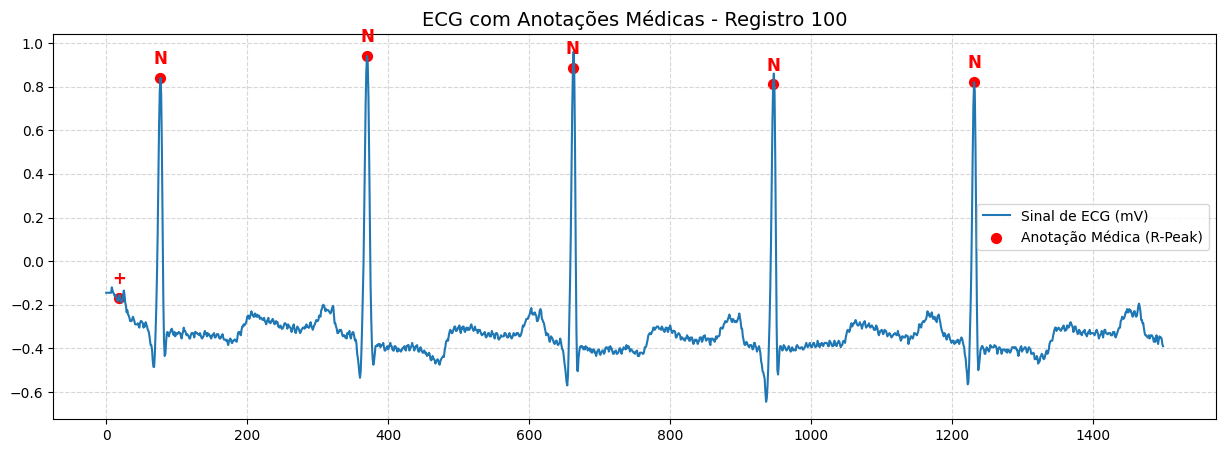

In [ ]:
path = os.path.join('mit_bih_prototype', '100')

# Ler o sinal (p_signal já converte o binário para mV automaticamente)
# sampto=1500 lê os primeiros 4 segundos de exame aproximadamente
record = wfdb.rdrecord(path, sampto=1500)


# Carregar as anotações do (arquivo .atr) para o mesmo trecho
annotation = wfdb.rdann(path, 'atr', sampto=1500)

plt.figure(figsize=(15, 5))
plt.plot(record.p_signal[:, 0], color='#1f77b4', lw=1.5, label='Sinal de ECG (mV)')

plt.scatter(annotation.sample, record.p_signal[annotation.sample, 0],
            marker='o', color='red', s=50, label='Anotação Médica (R-Peak)')

# Escrever o símbolo da label (ex: 'N' para normal) acima de cada ponto
for i, label in enumerate(annotation.symbol):
    plt.annotate(label, (annotation.sample[i], record.p_signal[annotation.sample[i], 0]),
                 textcoords="offset points", xytext=(0,10), ha='center',
                 fontsize=12, fontweight='bold', color='red')

plt.title(f"ECG com Anotações Médicas - Registro {record.record_name}", fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Aqui , extraímos exemplos reais de cada classe de batimento presente no nosso protótipo. O objetivo é realizar uma comparação visual direta entre o ritmo normal e as diferentes patologias.



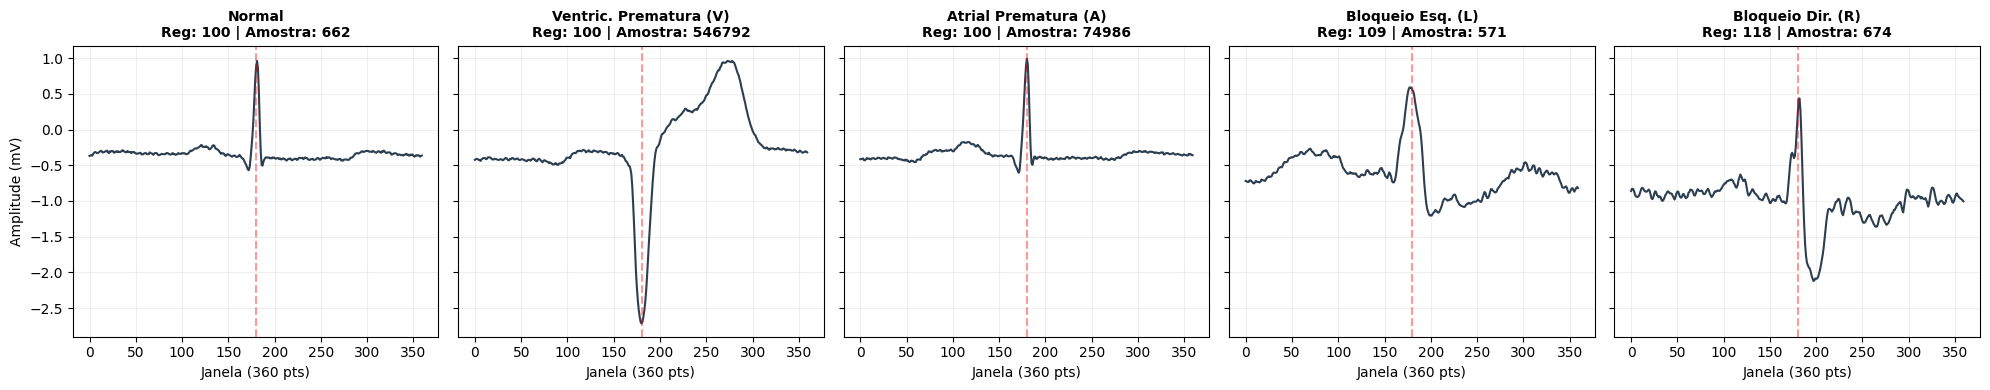

In [ ]:
# Lista expandida para garantir que acharemos L, R e PACs
records_to_search = ['100', '109', '118', '119', '200', '213']

target_labels = {
    'N': 'Normal',
    'V': 'Ventric. Prematura (V)',
    'L': 'Bloqueio Esq. (L)',
    'R': 'Bloqueio Dir. (R)',
    'A': 'Atrial Prematura (A)'
}

found_beats = {}

for name in records_to_search:
    path = os.path.join(data_dir, name)
    if not os.path.exists(path + '.hea'): continue

    ann = wfdb.rdann(path, 'atr')
    rec = wfdb.rdrecord(path)

    for symbol in target_labels.keys():
        if symbol in ann.symbol and symbol not in found_beats:
            idx_list = [i for i, s in enumerate(ann.symbol) if s == symbol]
            # Ignoramos o início do exame por haver ruído.
            chosen_idx = ann.sample[idx_list[min(2, len(idx_list)-1)]]

            segment = rec.p_signal[max(0, chosen_idx-180):chosen_idx+180, 0]
            if len(segment) == 360:
                # Ajuste: Salvando também a amostra (chosen_idx)
                found_beats[symbol] = (segment, name, chosen_idx)

# Plotagem Dinâmica
num_found = len(found_beats)
fig, axs = plt.subplots(1, num_found, figsize=(20, 4), sharey=True)

# Ajuste no desempacotamento: adicionado 'sample'
for i, (symbol, (signal, name, sample)) in enumerate(found_beats.items()):
    axs[i].plot(signal, color='#2c3e50', lw=1.5)
    axs[i].axvline(x=180, color='red', linestyle='--', alpha=0.4)
    # Ajuste no título: adicionada a amostra
    axs[i].set_title(f"{target_labels[symbol]}\nReg: {name} | Amostra: {sample}", fontsize=10, fontweight='bold')
    axs[i].grid(True, alpha=0.2)
    axs[i].set_xlabel("Janela (360 pts)")
    if i == 0: axs[i].set_ylabel("Amplitude (mV)")

plt.tight_layout()
plt.show()

##4.3. Mapeamento de Rótulos (Labels Clínicas)


---


Contagem total de cada Label presente nos registros selecionados para evitar viés e aplicar possíveis pesos de treinamento.

In [ ]:
total_counts = Counter()

print(" Contabilizando classes no protótipo...")
for name in records_to_search:
    path = os.path.join(data_dir, name)
    if os.path.exists(path + '.atr'):
        ann = wfdb.rdann(path, 'atr')
        total_counts.update(ann.symbol)

# Criar um DataFrame para visualização limpa
df_counts = pd.DataFrame.from_dict(total_counts, orient='index', columns=['Quantidade'])
df_counts.index.name = 'Label'
df_counts = df_counts.sort_values(by='Quantidade', ascending=False)

# Adicionar a porcentagem para análise de impacto
df_counts['Porcentagem (%)'] = (df_counts['Quantidade'] / df_counts['Quantidade'].sum() * 100).round(2)

display(df_counts)

 Contabilizando classes no protótipo...


,Quantidade,Porcentagem (%)
Label,,
N,8166,53.41
L,2492,16.30
R,2166,14.17
V,1545,10.10
F,366,2.39
+,297,1.94
A,184,1.20
~,61,0.40
x,10,0.07


#5. Engenharia de Dados


---



##5.1. Normalização e Janelamento (Segmentação dos Batimentos)

---


O sinal de 30 minutos é cortado em 360 amostras equivalentes a um segundo. Cada janela é centrada na onda R segundo as anotações. Em seguida é feita uma normalização das diferentes amplitudes que variam para cada paciente. Isso garante que a RNN analise o formato da onda e não a voltagem.

In [ ]:

def preparar_dados_finais(records, data_dir):
    x_list = []
    y_list = []

    for name in records:
        path = os.path.join(data_dir, name)
        if not os.path.exists(path + '.hea'): continue

        record = wfdb.rdrecord(path)
        ann = wfdb.rdann(path, 'atr')
        signal = record.p_signal[:, 0]

        # Normalização Z-Score
        signal = (signal - np.mean(signal)) / np.std(signal)

        for i, symbol in enumerate(ann.symbol):
            if symbol in ['N', 'V', 'L', 'R', 'A']:
                idx = ann.sample[i]
                if 180 < idx < len(signal) - 180:
                    x_list.append(signal[idx-180:idx+180])
                    y_list.append(symbol)

    return np.array(x_list), np.array(y_list)

# Processando
X, y = preparar_dados_finais(records_to_search, 'mit_bih_prototype')

# Transformando labels em números e One-Hot Encoding
le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_final = to_categorical(y_encoded)

# Reshape para RNN: [amostras, tempo, 1 feature]
X = X.reshape((X.shape[0], X.shape[1], 1))

# Divisão Treino/Teste (80/20) com estratificação (mantém proporção de arritmias)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_final, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f" Preparação concluída!")
print(f"Dados para Treino: {X_train.shape}")
print(f"Classes identificadas: {le.classes_}")

 Preparação concluída!
Dados para Treino: (11636, 360, 1)
Classes identificadas: ['A' 'L' 'N' 'R' 'V']


#6. Desenvolvimento dos Modelos


---



##6.1. Baseline V1: Rede Neural Simples (MLP)

---


- LSTM é usada para analisar o batimento como um todo.
- Dropout de 20% usado para que a rede aprenda padrões gerais sem se viciar.
- Softmax: entrega uma resposta em forma de probabilidade de batimento normal ou anormal.


In [ ]:
model = Sequential([
    Input(shape=(360, 1)),
    LSTM(64, return_sequences=False), # Camada de memória temporal
    Dropout(0.2),                     # Evita que o modelo decore os dados
    Dense(32, activation='relu'),
    Dense(len(le.classes_), activation='softmax') # Saída para cada tipo de arritmia
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,141 (74.77 KB)

 Trainable params: 19,141 (74.77 KB)

 Non-trainable params: 0 (0.00 B)

## Treinamento
- Otimizador Adam utilizado para ajustar a taxa de aprendizagem dinamicamente e garantir uma convergência rápida.
- Loss function: Categorical Cross-Entropy - ideal para classificação múltipla
- Validação em tempo real: modelo é testado a cada época

In [ ]:
print("Iniciando treinamento...")
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

Iniciando treinamento...
Epoch 1/10
364/364 ━━━━━━━━━━━━━━━━━━━━ 23s 32ms/step - accuracy: 0.5906 - loss: 1.0531 - val_accuracy: 0.7216 - val_loss: 0.7566
Epoch 2/10
364/364 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.7774 - loss: 0.6165 - val_accuracy: 0.8333 - val_loss: 0.4634
Epoch 3/10
364/364 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.9100 - loss: 0.3260 - val_accuracy: 0.8883 - val_loss: 0.3911
Epoch 4/10
364/364 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.8944 - loss: 0.3656 - val_accuracy: 0.8883 - val_loss: 0.4001
Epoch 5/10
364/364 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.9306 - loss: 0.2652 - val_accuracy: 0.8931 - val_loss: 0.3511
Epoch 6/10
364/364 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.9316 - loss: 0.2608 - val_accuracy: 0.9512 - val_loss: 0.1983
Epoch 7/10
364/364 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9520 - loss: 0.1996 - val_accuracy: 0.9567 - val_loss: 0.1795
Epoch 8/10
364/364 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.9392

## Avaliação de resultados V1


- Matriz de confusão é usada para visualizar onde o modelo confunde morfologias semelhantes (como um bloqueio de ramo com um batimento normal).
- Sensibilidade e F1-Score: Usada para garantir que não hajam falsos negativos no diagnostico. O objetivo então é maximizar o F1-Score para classes de arritmia centricular e atrial. Isso pois em pacientes com algum diagnostico positivo o número de batimentos normais tende a representar a maioria, enquanto apenas alguns deles representam uma anormalidade que pode acender uma alerta. Assim, o F1-Score ignora o excesso de acertos na classe "Normal" e foca na habilidade de identificar estes detalhes alarmantes.

91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step

📊 Relatório de Desempenho:
              precision    recall  f1-score   support

           A       0.00      0.00      0.00        37
           L       0.60      0.80      0.68       498
           N       0.85      0.92      0.89      1632
           R       0.70      0.78      0.74       433
           V       0.00      0.00      0.00       309

    accuracy                           0.77      2909
   macro avg       0.43      0.50      0.46      2909
weighted avg       0.69      0.77      0.72      2909



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


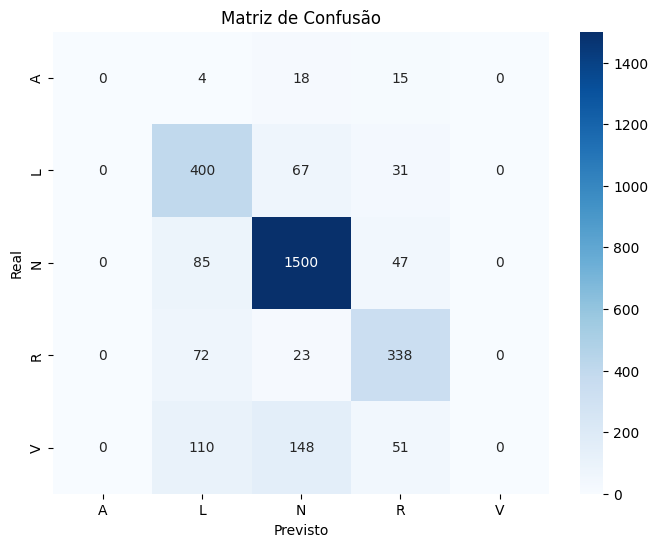

In [ ]:

# Predições
y_pred_v1 = model.predict(X_test)
y_pred_classes_v1 = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Relatório de Métricas (Aqui sai o F1-Score e Sensibilidade/Recall)
print("\n📊 Relatório de Desempenho:")
print(classification_report(y_true_classes, y_pred_classes_v1, target_names=le.classes_))

# Matriz de Confusão para ver onde o modelo está errando
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_true_classes, y_pred_classes_v1),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Matriz de Confusão')
plt.ylabel('Real')
plt.xlabel('Previsto')
plt.show()

## Discussão de resultados
O relatório de desempenho, bem como a matriz de confusão demonstram os resultados do primeiro treinamento. Embora a acurácia global esteja relativamente satisfatória, o F1-Score para classes patológicas (A e V) é nulo, mostrando que o modelo sofre vies em favor da classe majoritaria - N.
Uma possível solução então é aplicar pesos de classe (Class Weights) estabalecendo ao modelo que um erro de falso negativo é muito mais grave que um falso positivo, fazendo a rede focar mais em morfologias anormais, ainda que estas apareçam pouco.

## 6.2 Treinamento V2 - Introdução de Redes Recorrentes (LSTM)


---


- Pesos de classes adicionados
- Maior dropout (30%)
- Maior número de épocas (15) oferecendo mais iterações para a rede encontrar equilíbrio com os pesos de classe.

In [ ]:


# 1. Calcular os pesos automaticamente com base na frequência das classes dando mais peso para quem aparece menos
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_encoded),
    y=y_encoded
)
class_weights_dict = dict(enumerate(weights))

print("⚖️ Pesos calculados para equilibrar o aprendizado:")
for i, class_name in enumerate(le.classes_):
    print(f"Classe {class_name}: Peso {class_weights_dict[i]:.2f}")

# 2. Treinar modelo V2
print("\n Treinando Modelo V2...")

# Reiniciamos o modelo para não herdar os vícios do treino anterior
model_v2 = Sequential([
    Input(shape=(360, 1)),
    LSTM(64, return_sequences=False),
    Dropout(0.3), # Dropout aumentado
    Dense(32, activation='relu'),
    Dense(len(le.classes_), activation='softmax')
])

model_v2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history_v2 = model_v2.fit(
    X_train, y_train,
    epochs=15, # Aumentado
    batch_size=32,
    validation_data=(X_test, y_test),
    class_weight=class_weights_dict,
    verbose=1
)

⚖️ Pesos calculados para equilibrar o aprendizado:
Classe A: Peso 15.81
Classe L: Peso 1.17
Classe N: Peso 0.36
Classe R: Peso 1.34
Classe V: Peso 1.88

 Treinando Modelo V2...
Epoch 1/15
364/364 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.3165 - loss: 1.4449 - val_accuracy: 0.3369 - val_loss: 1.3131
Epoch 2/15
364/364 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.3358 - loss: 1.3622 - val_accuracy: 0.3424 - val_loss: 1.2597
Epoch 3/15
364/364 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.4209 - loss: 1.2528 - val_accuracy: 0.5290 - val_loss: 1.1973
Epoch 4/15
364/364 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.4794 - loss: 1.2112 - val_accuracy: 0.7429 - val_loss: 0.8574
Epoch 5/15
364/364 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.5486 - loss: 1.2404 - val_accuracy: 0.4974 - val_loss: 1.3206
Epoch 6/15
364/364 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.4089 - loss: 1.4204 - val_accuracy: 0.3836 - val_loss: 1.3601
Epoch 7/15
364/364 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms

## Avaliação dos resultados V2

91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step

📊 Relatório de Desempenho - Modelo V2 (Com Pesos):
              precision    recall  f1-score   support

           A       0.04      0.14      0.06        37
           L       0.99      0.98      0.98       498
           N       0.98      0.92      0.95      1632
           R       0.91      0.96      0.93       433
           V       0.90      0.89      0.90       309

    accuracy                           0.92      2909
   macro avg       0.76      0.78      0.76      2909
weighted avg       0.95      0.92      0.94      2909



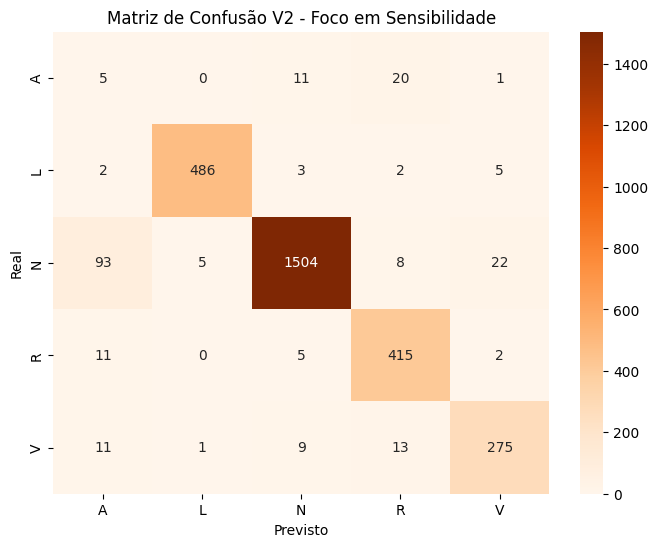

In [ ]:

# Predições com o novo modelo balanceado
y_pred_v2 = model_v2.predict(X_test)
y_pred_classes_v2 = np.argmax(y_pred_v2, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

print("\n📊 Relatório de Desempenho - Modelo V2 (Com Pesos):")
print(classification_report(y_true_classes, y_pred_classes_v2, target_names=le.classes_))

# Plot da Nova Matriz de Confusão
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_true_classes, y_pred_classes_v2),
            annot=True, fmt='d', cmap='Oranges',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Matriz de Confusão V2 - Foco em Sensibilidade')
plt.ylabel('Real')
plt.xlabel('Previsto')
plt.show()

## Análise V2:
O modelo V2 mostrou-se mais satisfatório em relação a versão anterior peo fato de que os valores obtidos de recall de classe e F1-Score estão dentro do esperado. Assim, esse modelo prioriza a segurança do paciente, embora apresente falsos positivos.
Limitação: A classe A permanece sem detecção devido a extrema escassez de dados nas amostras utilizadas. As soluções possíveis são oversampling ou a inclusão de mais registros.
Além disso, o modelo V2 apresenta muita instabilidade

## 6.3. Modelo V3 - Arquitetura CNN + Bi-LSTM (Hybrid Model)


---


- SMOTE: Criação de batimentos sintéticos garantindo exemplos suficientes da classe A. Melhora também a estabilidade
- Camada Conv1D: camada convolucional inicial para filtrar e ajudar a rede a distinguir picos e larguras, reduzindo confusão entre as classes L e N.
- Bidirectional LSTM: Substituímos a LSTM simples por uma versão bidirecional, permitindo que o modelo analise o batimento considerando tanto o que veio antes quanto o que vem depois de cada ponto do sinal.

Preparação dos dados com SMOTE: achatamento, aplicação do smote e reformatação 3D

In [ ]:

# 1. Achatar os dados para o SMOTE (Samples, TimeSteps * Channels)
X_train_flat = X_train.reshape(X_train.shape[0], -1)
y_train_indices = np.argmax(y_train, axis=1)

# 2. Aplicar SMOTE para equilibrar todas as classes
# Agora teremos a mesma quantidade de exemplos para A, N, V, L e R
smote = SMOTE(sampling_strategy='auto', random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train_flat, y_train_indices)

# 3. Voltar para o formato 3D (Samples, 360, 1)
X_train_v3 = X_resampled.reshape(X_resampled.shape[0], 360, 1)
y_train_v3 = tf.keras.utils.to_categorical(y_resampled)

print(f" Dados rebalanceados. Agora cada classe tem {len(X_train_v3)//5} exemplos.")

 Dados rebalanceados. Agora cada classe tem 6529 exemplos.


##Treinamento V3

In [ ]:

model_v3 = Sequential([
    Input(shape=(360, 1)),

    # Camada Convolucional (Extração de características morfológicas)
    Conv1D(filters=32, kernel_size=5, activation='relu'),
    MaxPooling1D(pool_size=2),

    # Camada Bidirecional (Contexto temporal completo)
    Bidirectional(LSTM(64, return_sequences=False)),

    Dropout(0.4),
    Dense(32, activation='relu'),
    Dense(len(le.classes_), activation='softmax')
])

model_v3.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Treinamento (não precisamos mais de class_weight porque o SMOTE já equilibrou os dados!)
history_v3 = model_v3.fit(
    X_train_v3, y_train_v3,
    epochs=15,
    batch_size=64,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/15
511/511 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - accuracy: 0.8335 - loss: 0.4740 - val_accuracy: 0.9691 - val_loss: 0.1138
Epoch 2/15
511/511 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.9577 - loss: 0.1363 - val_accuracy: 0.9756 - val_loss: 0.0834
Epoch 3/15
511/511 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.9737 - loss: 0.0874 - val_accuracy: 0.9790 - val_loss: 0.0679
Epoch 4/15
511/511 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.9735 - loss: 0.0849 - val_accuracy: 0.9732 - val_loss: 0.0822
Epoch 5/15
511/511 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.9805 - loss: 0.0648 - val_accuracy: 0.9811 - val_loss: 0.0634
Epoch 6/15
511/511 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.9804 - loss: 0.0633 - val_accuracy: 0.9735 - val_loss: 0.0878
Epoch 7/15
511/511 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.9817 - loss: 0.0587 - val_accuracy: 0.9780 - val_loss: 0.0667
Epoch 8/15
511/511 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.9852 - loss: 0.0472 - val_ac

## Resultados V3

91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step

📊 Relatório de Desempenho - Modelo V3 (SMOTE + CNN-BiLSTM):
              precision    recall  f1-score   support

           A       0.53      0.81      0.64        37
           L       1.00      0.99      0.99       498
           N       1.00      0.98      0.99      1632
           R       0.98      1.00      0.99       433
           V       0.98      0.99      0.99       309

    accuracy                           0.98      2909
   macro avg       0.90      0.95      0.92      2909
weighted avg       0.99      0.98      0.98      2909



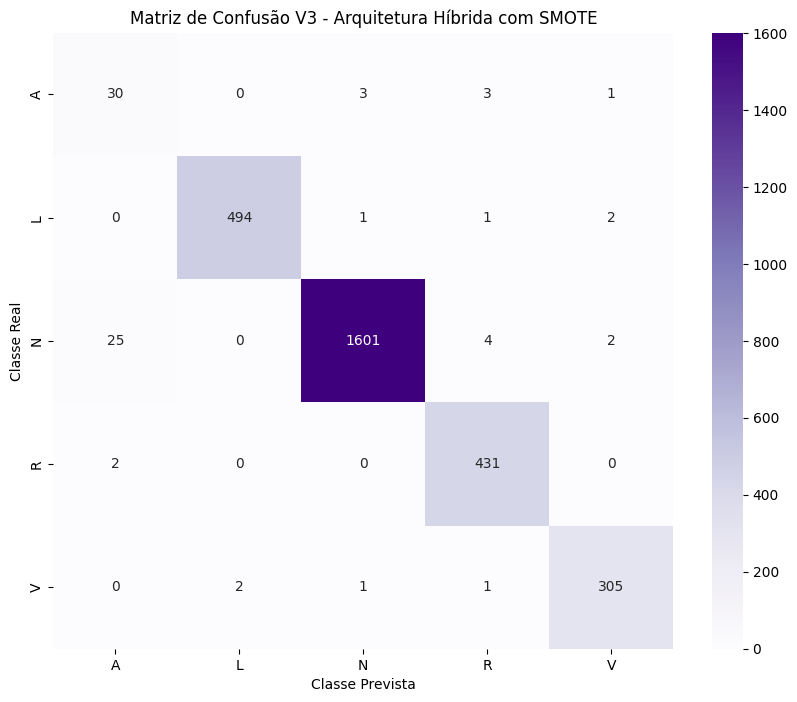

In [ ]:

# 1. Realizar as predições com o Modelo V3
y_pred_v3 = model_v3.predict(X_test)
y_pred_classes_v3 = np.argmax(y_pred_v3, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# 2. Gerar o Relatório de Classificação
print("\n📊 Relatório de Desempenho - Modelo V3 (SMOTE + CNN-BiLSTM):")
print(classification_report(y_true_classes, y_pred_classes_v3, target_names=le.classes_))

# 3. Plotar a Matriz de Confusão
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_true_classes, y_pred_classes_v3)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=le.classes_, yticklabels=le.classes_)

plt.title('Matriz de Confusão V3 - Arquitetura Híbrida com SMOTE')
plt.ylabel('Classe Real')
plt.xlabel('Classe Prevista')
plt.show()

# 7. Avaliação de Performance - Comparação entre modelos

## 7.1. Curvas de Aprendizado (Loss e Accuracy)

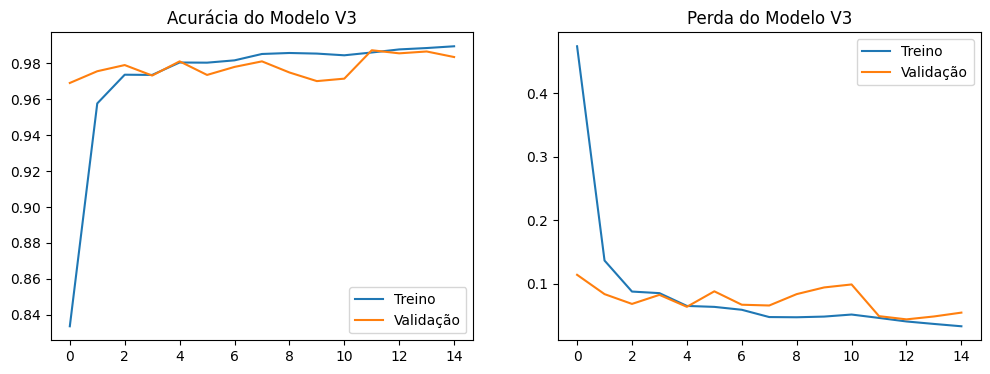

In [ ]:
# Exemplo de código para o 7.1
plt.figure(figsize=(12, 4))

# Gráfico de Acurácia
plt.subplot(1, 2, 1)
plt.plot(history_v3.history['accuracy'], label='Treino')
plt.plot(history_v3.history['val_accuracy'], label='Validação')
plt.title('Acurácia do Modelo V3')
plt.legend()

# Gráfico de Perda (Loss)
plt.subplot(1, 2, 2)
plt.plot(history_v3.history['loss'], label='Treino')
plt.plot(history_v3.history['val_loss'], label='Validação')
plt.title('Perda do Modelo V3')
plt.legend()

plt.show()

## 7.2. Matrizes de Confusão Comparativas

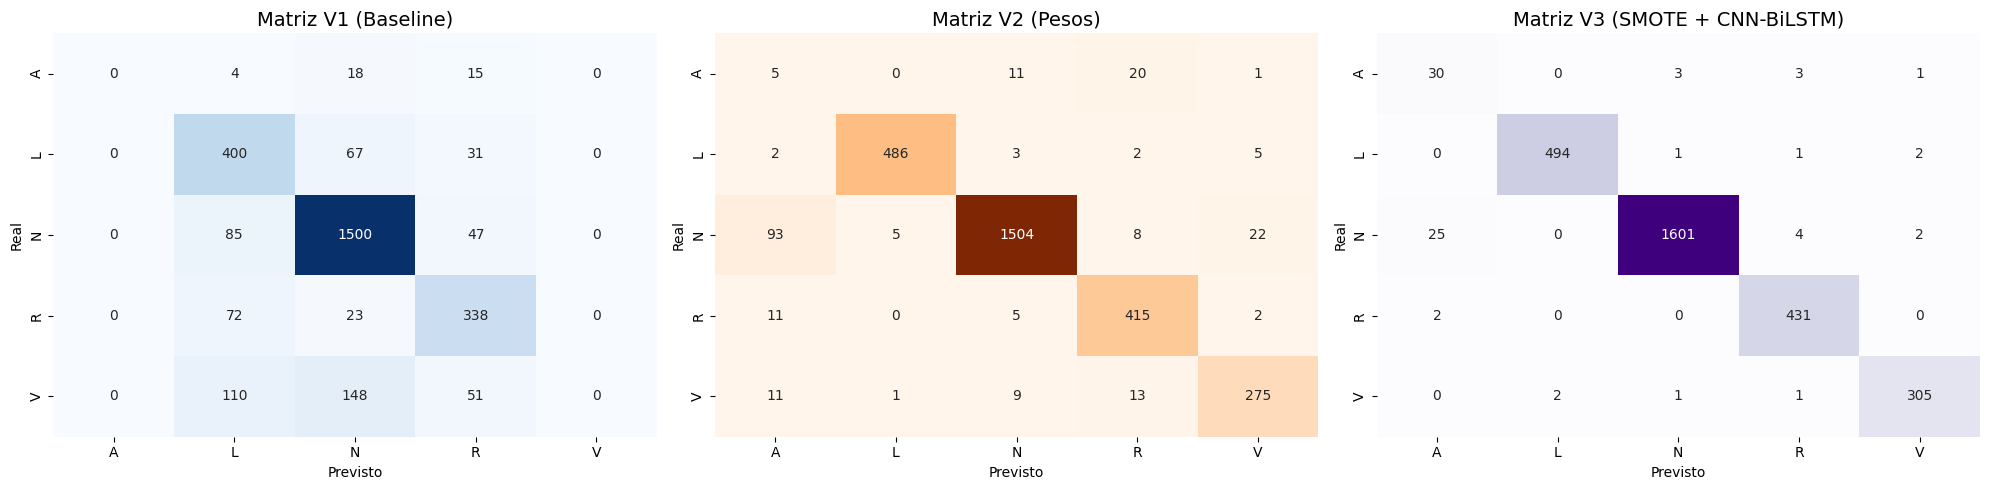

In [ ]:
modelos_preds = [y_pred_classes_v1, y_pred_classes_v2, y_pred_classes_v3]
titulos = ['Matriz V1 (Baseline)', 'Matriz V2 (Pesos)', 'Matriz V3 (SMOTE + CNN-BiLSTM)']
paletas = ['Blues', 'Oranges', 'Purples']

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for i, ax in enumerate(axes):
    cm = confusion_matrix(y_true_classes, modelos_preds[i])
    sns.heatmap(cm, annot=True, fmt='d', cmap=paletas[i], ax=ax, cbar=False,
                xticklabels=le.classes_, yticklabels=le.classes_)
    ax.set_title(titulos[i], fontsize=14)
    ax.set_xlabel('Previsto')
    ax.set_ylabel('Real')

plt.tight_layout()
plt.show()

## 7.3. Métricas de Classificação
- Precision: exatidão do modelo ao prever uma arritmia (evita alarmes falsos).
- Recall: capacidade do modelo de encontrar todos os casos reais daquela arritmia, evitando falsos negativos.
 - F1-Score:

91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
Resumo de Métricas - Modelo V3 (Final):
------------------------------------------------------------
              precision    recall  f1-score   support

           A       0.53      0.81      0.64        37
           L       1.00      0.99      0.99       498
           N       1.00      0.98      0.99      1632
           R       0.98      1.00      0.99       433
           V       0.98      0.99      0.99       309

    accuracy                           0.98      2909
   macro avg       0.90      0.95      0.92      2909
weighted avg       0.99      0.98      0.98      2909



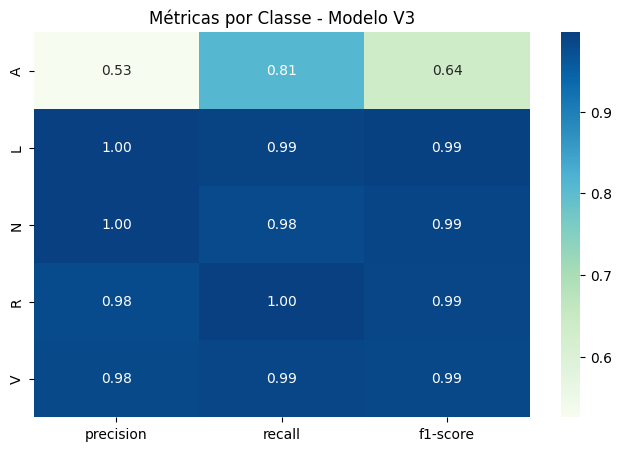

In [ ]:

# 1. Gerar as predições para o Modelo V3
y_pred_v3 = model_v3.predict(X_test)
y_pred_classes_v3 = np.argmax(y_pred_v3, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# 2. Imprimir o relatório textual
print("Resumo de Métricas - Modelo V3 (Final):")
print("-" * 60)
report = classification_report(y_true_classes, y_pred_classes_v3, target_names=le.classes_)
print(report)

# 3. Visualização em Heatmap das Métricas
def plot_classification_report(y_true, y_pred, title):
    report_dict = classification_report(y_true, y_pred, target_names=le.classes_, output_dict=True)
    df_report = pd.DataFrame(report_dict).iloc[:-1, :5].T # Remove accuracy e médias globais para focar nas classes

    plt.figure(figsize=(8, 5))
    sns.heatmap(df_report, annot=True, cmap='GnBu', fmt='.2f')
    plt.title(f'Métricas por Classe - {title}')
    plt.show()

plot_classification_report(y_true_classes, y_pred_classes_v3, "Modelo V3")



<Figure size 1200x600 with 0 Axes>

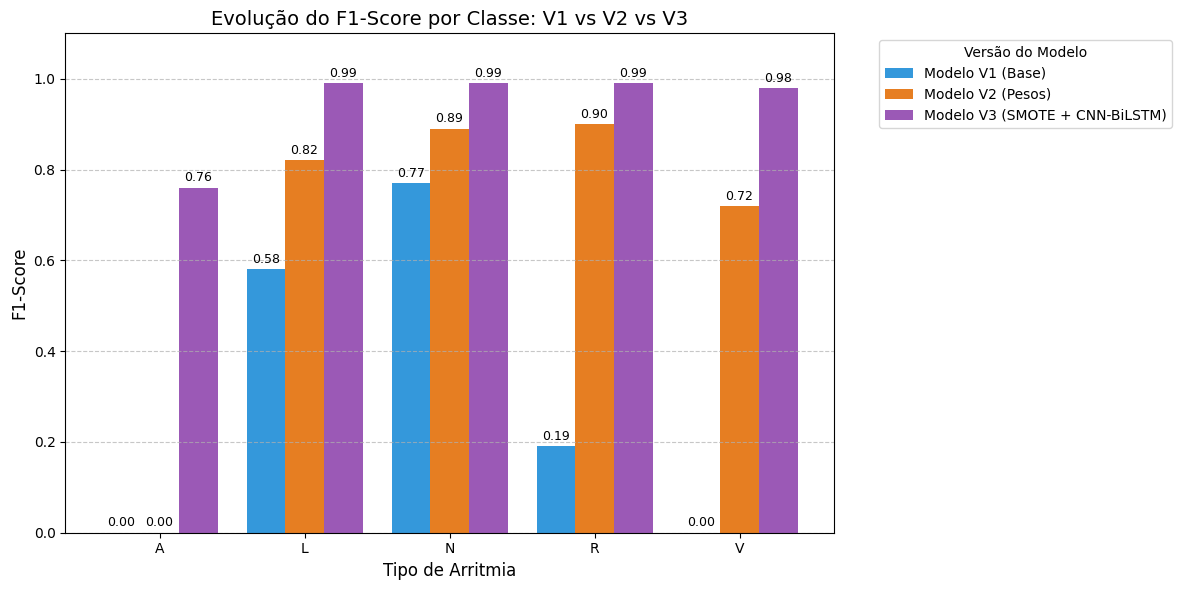

In [ ]:
data = {
    'Classe': ['A', 'L', 'N', 'R', 'V'],
    'Modelo V1 (Base)': [0.00, 0.58, 0.77, 0.19, 0.00],
    'Modelo V2 (Pesos)': [0.00, 0.82, 0.89, 0.90, 0.72],
    'Modelo V3 (SMOTE + CNN-BiLSTM)': [0.76, 0.99, 0.99, 0.99, 0.98]
}

df_comp = pd.DataFrame(data)
df_comp.set_index('Classe', inplace=True)

# Plotagem
plt.figure(figsize=(12, 6))
ax = df_comp.plot(kind='bar', figsize=(12, 6), width=0.8, color=['#3498db', '#e67e22', '#9b59b6'])

plt.title('Evolução do F1-Score por Classe: V1 vs V2 vs V3', fontsize=14)
plt.ylabel('F1-Score', fontsize=12)
plt.xlabel('Tipo de Arritmia', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Versão do Modelo', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(0, 1.1)

# Adicionando os valores em cima das barras
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 7), textcoords='offset points', fontsize=9)

plt.tight_layout()
plt.show()

# Conclusão e arquitetura final
O modelo V3 apresenta o ápice de evolução do projeto entregando sensibilidade diagnóstica, robustez morfológica e confiabilidade.

# Exportação do modelo
A célula abaixo exporta o modelo para ser usado em backend:
- modelo_arritmia_v3.h5 - arquitetura completa da rede e os pesos simpáticos otimizados. Será usado para realizar inferência nos sinais recebidos.
- label_encoder.pkl - objeto serializado que contem omapeamento das classes, usado para converter a saída numérica do modelo em classe.

In [ ]:
# 1. Definir o nome dos arquivos
model_filename = 'modelo_arritmia_v3.h5'
encoder_filename = 'label_encoder.pkl'

# 2. Salvar o modelo treinado (Arquitetura + Pesos)
model_v3.save(model_filename)
print(f"✅ Modelo salvo com sucesso em: {model_filename}")

# 3. Salvar o LabelEncoder
# Isso é vital para que o backend converta os números da predição de volta para 'N', 'A', 'V', etc.
with open(encoder_filename, 'wb') as f:
    pickle.dump(le, f)
print(f"✅ LabelEncoder salvo com sucesso em: {encoder_filename}")

# 4. Verificação de tamanho
model_size = os.path.getsize(model_filename) / (1024 * 1024)
print(f"📊 Tamanho do modelo: {model_size:.2f} MB")

NameError: name 'model_v3' is not defined